In [5]:
%pip install pandas openpyxl pyxlsb matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
import os
import warnings
# Force Python à ignorer tous les avertissements visuels de type "FutureWarning" ou "DeprecationWarning"
warnings.filterwarnings('ignore')

# 1. Définition du chemin de base vers votre dossier de projet
base_path = "/Users/VirginiePerrier/Desktop/Desktop - Virginie’s MacBook/Ongoing/Projet N°10/"

print("⏳ Lancement du chargement des données pour UOI Games...\n")

# --- CHARGEMENT DU FICHIER 1 : HISTORIQUE DES VENTES (.xlsb) ---
try:
    path_sales = os.path.join(base_path, "sales_history.xlsb")
    df_sales_hist = pd.read_excel(path_sales, engine='pyxlsb')
    print("✅ 1/3 - Historique des ventes (sales_history) chargé avec succès !")
except Exception as e:
    print(f"❌ Erreur sur sales_history.xlsb : {e}")

# --- CHARGEMENT DU FICHIER 2 : PUBLICATIONS 2022 (.xlsb) ---
try:
    path_publish = os.path.join(base_path, "publish_2022.xlsb")
    df_pub_2022 = pd.read_excel(path_publish, engine='pyxlsb')
    print("✅ 2/3 - Base des publications (publish_2022) chargée avec succès !")
except Exception as e:
    print(f"❌ Erreur sur publish_2022.xlsb : {e}")

# --- CHARGEMENT DU FICHIER 3 : VENTES DE CONSOLES (.xlsx) ---
try:
    path_consoles = os.path.join(base_path, "consoles_2022.xlsx")
    df_consoles = pd.read_excel(path_consoles)
    print("✅ 3/3 - Ventes de consoles (consoles_2022) chargées avec succès !")
except Exception as e:
    print(f"❌ Erreur sur consoles_2022.xlsx : {e}")

print("\n📊 Tout est prêt en mémoire. Les analyses peuvent commencer.")

⏳ Lancement du chargement des données pour UOI Games...

✅ 1/3 - Historique des ventes (sales_history) chargé avec succès !
❌ Erreur sur publish_2022.xlsb : [Errno 2] No such file or directory: '/Users/VirginiePerrier/Desktop/Desktop - Virginie’s MacBook/Ongoing/Projet N°10/publish_2022.xlsb'
✅ 3/3 - Ventes de consoles (consoles_2022) chargées avec succès !

📊 Tout est prêt en mémoire. Les analyses peuvent commencer.


In [5]:
# Afficher les dimensions (lignes, colonnes) et les premières lignes de chaque tableau
print("Structure de la base Historique :", df_sales_hist.shape)
display(df_sales_hist.head(3))

print("\nStructure de la base Publications 2022 :", df_pub_2022.shape)
display(df_pub_2022.head(3))

print("\nStructure de la base Consoles :", df_consoles.shape)
display(df_consoles.head(3))

Structure de la base Historique : (16545, 13)


,Rank,Name,Platform,Year,Genre,Publisher,Constructeur,Portable,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,Nintendo,Non,41.4900,27.8592,3.6569,8.2908,81.2969
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,Nintendo,Non,29.9524,3.4726,6.6738,0.8085,40.9073
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,Nintendo,Non,15.2160,12.4936,3.7900,3.3762,34.8758



Structure de la base Publications 2022 : (440896, 67)


,id,slug,name,metacritic,released,Annee,tba,rating,rating_top,playtime,...,Apple II,NES,Dreamcast,PlayStation 5,Xbox Series S/X,Commodore / Amiga,Atari 26,Atari ST,Atari 78,SEGA Saturn
0,1,dgeneration-hd,D/Generation HD,NaN,42300,2015,False,0.0,0.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10,g-prime,G Prime Into The Rain,NaN,42375,2016,False,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100,land-sliders,Land Sliders,NaN,42271,2015,False,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Structure de la base Consoles : (20, 4)


,Console,Constructeur,Date de Sortie,Vente (en million)
0,PlayStation 2,Sony,2000,158.0000
1,Nintendo DS,Nintendo,2004,157.1004
2,Switch,Nintendo,2017,126.8762


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Configuration de la charte graphique des diagrammes (style épuré)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Chemin racine de votre dossier de projet sur votre Mac
base_path = "/Users/VirginiePerrier/Desktop/Desktop - Virginie’s MacBook/Ongoing/Projet N°10/"
print("⚙️ Environnement prêt pour l'analyse d'UOI Games.")

⚙️ Environnement prêt pour l'analyse d'UOI Games.


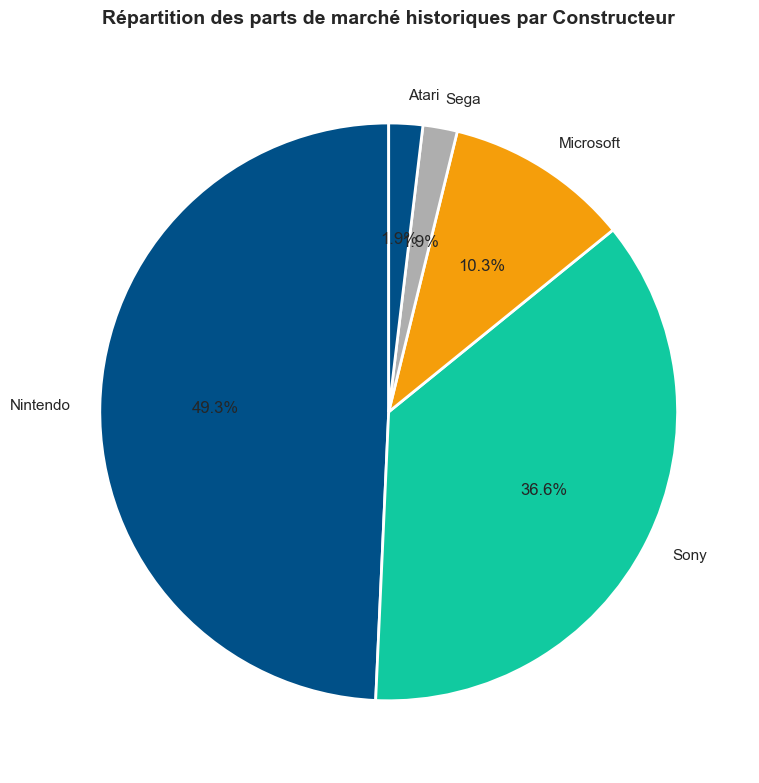

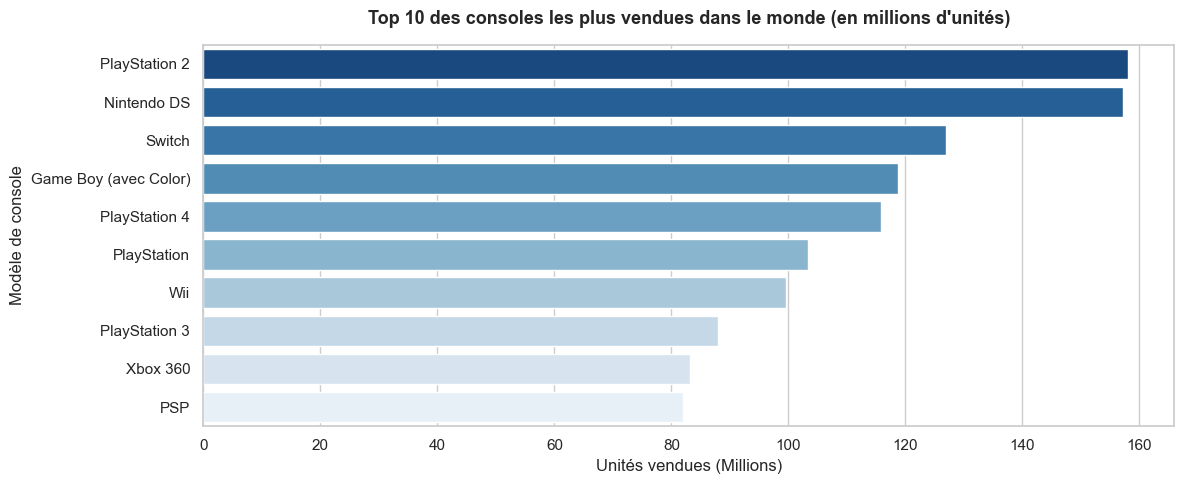

In [6]:
# Chargement du fichier matériel
df_consoles = pd.read_excel(os.path.join(base_path, "consoles_2022.xlsx"))

# 1. Calcul des parts de marché cumulées par Constructeur
market_share = df_consoles.groupby('Constructeur')['Vente (en million)'].sum().sort_values(ascending=False)

# Création du graphique en Camembert (Pie Chart)
plt.figure(figsize=(8, 8))
colors = ['#005088', '#11caa0', '#f59e0b', '#aeaeae'] # Palette pro calée sur vos slides
plt.pie(market_share, labels=market_share.index, autopct='%1.1f%%', startangle=90, colors=colors, 
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title("Répartition des parts de marché historiques par Constructeur", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# 2. Zoom sur le Top 10 des consoles les plus installées
top_10_consoles = df_consoles.sort_values(by='Vente (en million)', ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x='Vente (en million)', y='Console', data=top_10_consoles, palette="Blues_r")
plt.title("Top 10 des consoles les plus vendues dans le monde (en millions d'unités)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Unités vendues (Millions)")
plt.ylabel("Modèle de console")
plt.tight_layout()
plt.show()

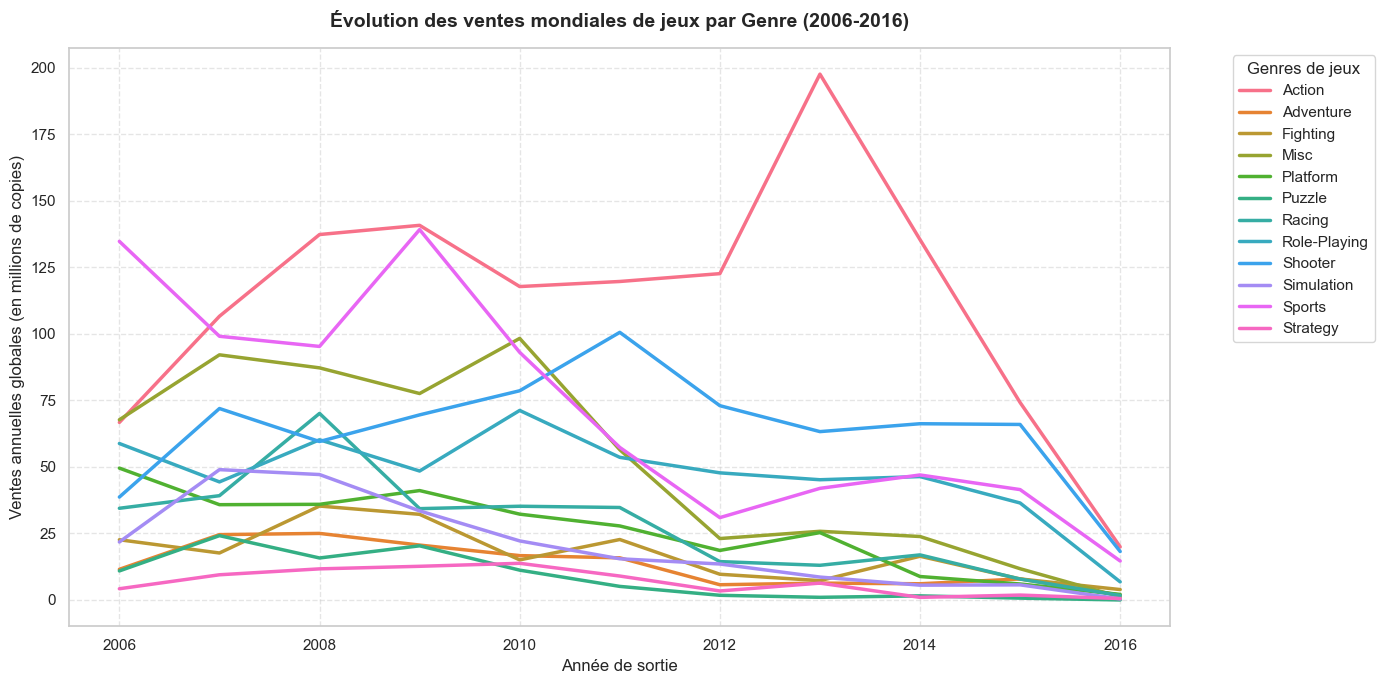

In [3]:
# Chargement de la base historique (1980-2016)
df_sales_hist = pd.read_excel(os.path.join(base_path, "sales_history.xlsb"), engine='pyxlsb')

# Filtrage sur la dernière décennie disponible pour capter les dynamiques modernes (2006-2016)
df_recent_sales = df_sales_hist[(df_sales_hist['Year'] >= 2006) & (df_sales_hist['Year'] <= 2016)]

# Évolution des ventes globales par Genre au fil des ans
genre_evolution = df_recent_sales.groupby(['Year', 'Genre'])['Global_Sales'].sum().unstack().fillna(0)

# Création du graphique Linéaire (Line Chart)
plt.figure(figsize=(14, 7))
sns.lineplot(data=genre_evolution, dashes=False, linewidth=2.5)
plt.title("Évolution des ventes mondiales de jeux par Genre (2006-2016)", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Ventes annuelles globales (en millions de copies)")
plt.xlabel("Année de sortie")
plt.legend(title="Genres de jeux", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [14]:
# Étape 3 : Top & Flop des Moyennes par Genre et par Jeu (Sans Graphique)
# Configuration de départ
col_score = 'rating'
col_genre = 'genres'

try:
    # 1. Copie de travail et conversion numérique
    df_working = df_pub_2022.copy()
    df_working['Score_Numerique'] = pd.to_numeric(df_working[col_score], errors='coerce')
    
    # 2. Filtrage des données (Exclusion des notes manquantes et des 0.0)
    df_clean = df_working[(df_working['Score_Numerique'] > 0.0) & (df_working[col_genre].notna())]
    
    # ==========================================
    # 📊 PARTIE A : TOP / FLOP PAR GENRE UNIQUE
    # ==========================================
    # Uniformisation des séparateurs (remplacement des ; et | par des virgules)
    df_genres = df_clean.copy()
    df_genres['genres_uniformes'] = df_genres[col_genre].astype(str).str.replace(';', ',').str.replace('|', ',')
    
    # Séparation et explosion des genres multiples
    df_genres['genre_split'] = df_genres['genres_uniformes'].str.split(',')
    df_exploded = df_genres.explode('genre_split')
    df_exploded['genre_unique'] = df_exploded['genre_split'].str.strip()
    
    # Nettoyage des chaînes vides résiduelles
    df_exploded = df_exploded[df_exploded['genre_unique'] != '']
    
    # Calcul des statistiques par genre unique
    genre_stats = df_exploded.groupby('genre_unique')['Score_Numerique'].agg(['mean', 'count'])
    
    # ⚠️ FILTRE DE FIABILITÉ : On exclut les genres qui ont moins de 3 jeux dans la base 
    # pour éviter qu'un jeu obscur unique noté 10/10 ne fausse le Top.
    genre_stats_fiable = genre_stats[genre_stats['count'] >= 3]
    
    print("==========================================================")
    print("      🏆 ANALYSE DES GENRES (Moyennes réelles)            ")
    print("==========================================================")
    print(f"\n🥇 TOP 5 DES GENRES LES MIEUX NOTÉS :")
    print(genre_stats_fiable['mean'].sort_values(ascending=False).head(5).round(2))
    
    print(f"\n🔻 FLOP 5 DES GENRES LES MOINS BIEN NOTÉS :")
    print(genre_stats_fiable['mean'].sort_values(ascending=True).head(5).round(2))
    
    # ==========================================
    # 🎮 PARTIE B : TOP / FLOP PAR JEU
    # ==========================================
    # Détection de la colonne du nom du jeu
    col_jeu = [c for c in df_clean.columns if any(w in c.lower() for w in ['name', 'title', 'jeu', 'nom', 'titre'])]
    col_jeu = col_jeu[0] if col_jeu else df_clean.columns[0]
    
    # Calcul des moyennes par jeu (au cas où un jeu apparaîtrait plusieurs fois par plateforme)
    game_stats = df_clean.groupby(col_jeu)['Score_Numerique'].agg(['mean', 'count'])
    
    # Même filtre de fiabilité pour les votes des jeux (ex: au moins 2 évaluations)
    game_stats_fiable = game_stats.sort_values(by='mean', ascending=False)
    
    print("\n==========================================================")
    print("      🕹️ ANALYSE DES JEUX INDIVIDUELS                     ")
    print("==========================================================")
    print(f"\n🥇 TOP 10 DES JEUX LES MIEUX NOTÉS DU MARCHÉ :")
    print(game_stats_fiable['mean'].head(10).round(2))
    
    print(f"\n🔻 FLOP 10 DES JEUX LES PIRE NOTÉS DU MARCHÉ :")
    print(game_stats_fiable['mean'].tail(10).sort_values(ascending=True).round(2))

except Exception as e:
    print(f"❌ Une erreur est survenue lors du calcul des indicateurs bruts : {e}")
plt.show()

      🏆 ANALYSE DES GENRES (Moyennes réelles)            

🥇 TOP 5 DES GENRES LES MIEUX NOTÉS :
genre_unique
Platformer    3.61
Fighting      3.61
Family        3.50
Card          3.48
Shooter       3.47
Name: mean, dtype: float64

🔻 FLOP 5 DES GENRES LES MOINS BIEN NOTÉS :
genre_unique
Casual                   2.92
Massively Multiplayer    2.93
Indie                    3.02
Board Games              3.19
Educational              3.21
Name: mean, dtype: float64

      🕹️ ANALYSE DES JEUX INDIVIDUELS                     

🥇 TOP 10 DES JEUX LES MIEUX NOTÉS DU MARCHÉ :
name
The World Ends with You: Solo Remix              4.86
Kara no Shojo                                    4.83
Persona 5 Royal                                  4.81
Shovel Knight: Shovel of Hope                    4.78
The Witcher 3: Game of the Year                  4.77
Mass Effect Trilogy                              4.76
Cataclysm: Dark Days Ahead                       4.75
The Witcher 3: Wild Hunt - Blood and Wine    

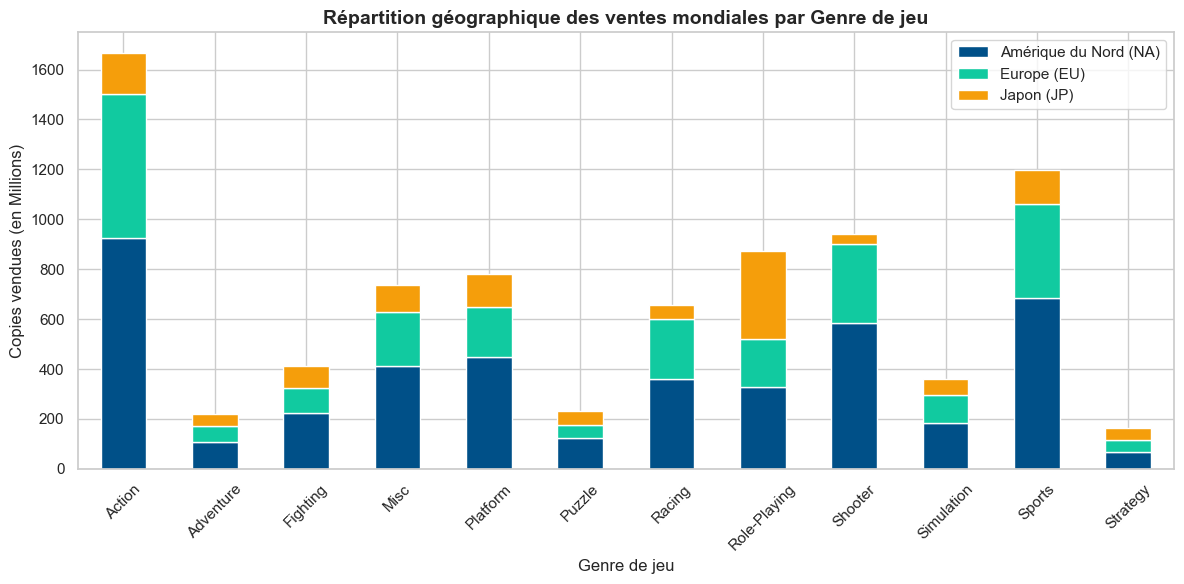

In [16]:
# Agrégation des ventes régionales par Genre
regional_sales = df_sales_hist.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales']].sum()

# Graphique en barres empilées (Stacked Bar Chart)
regional_sales.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#005088', '#11caa0', '#f59e0b'])
plt.title("Répartition géographique des ventes mondiales par Genre de jeu", fontsize=14, fontweight='bold')
plt.ylabel("Copies vendues (en Millions)")
plt.xlabel("Genre de jeu")
plt.xticks(rotation=45)
plt.legend(["Amérique du Nord (NA)", "Europe (EU)", "Japon (JP)"])
plt.tight_layout()
plt.show()

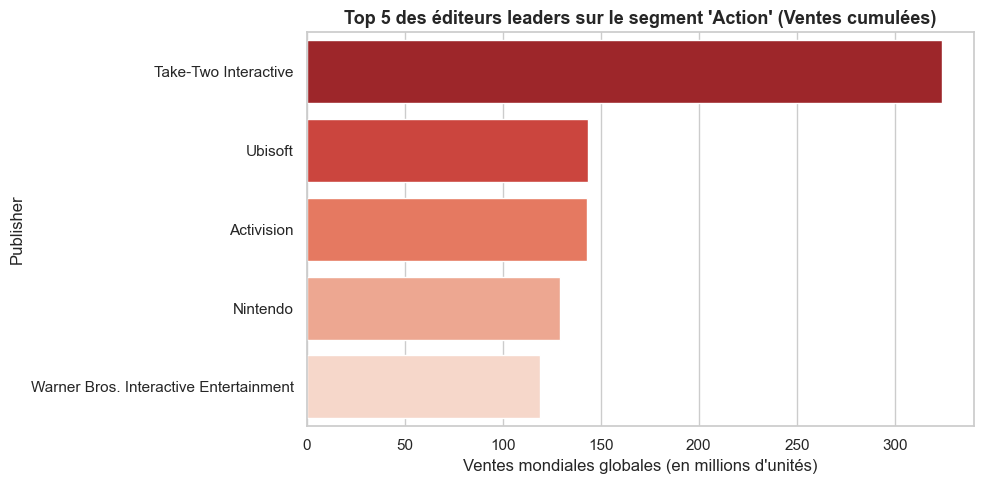

In [23]:
# --- ANALYSE COMPLÉMENTAIRE : CONCURRENCE ---
# 1. Filtrer sur le genre choisi (ex: Action) et identifier les gros éditeurs
genre_choisi = 'Action'
df_genre = df_sales_hist[df_sales_hist['Genre'] == genre_choisi]

top_publishers = df_genre.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(5)

# 2. Graphique de parts de marché des concurrents (Nettoyé)
plt.figure(figsize=(10, 5))
sns.barplot(
    x=top_publishers.values, 
    y=top_publishers.index, 
    hue=top_publishers.index,  # Évite le FutureWarning Seaborn
    palette="Reds_r", 
    legend=False               # Supprime la légende redondante
)

plt.title(f"Top 5 des éditeurs leaders sur le segment '{genre_choisi}' (Ventes cumulées)", fontsize=13, fontweight='bold')
plt.xlabel("Ventes mondiales globales (en millions d'unités)")
plt.tight_layout()
plt.show()

In [24]:
# Isoler les performances du genre choisi
sales_distribution = df_sales_hist[df_sales_hist['Genre'] == genre_choisi]['Global_Sales']

# Calcul des scénarios basés sur les percentiles réels du marché
scen_pessimiste = sales_distribution.quantile(0.25) # Le premier quart des ventes
scen_realiste   = sales_distribution.median()       # La médiane du marché
scen_optimiste  = sales_distribution.quantile(0.75) # Le top 25% des succès

print(f"📈 MODÉLISATION DES PRÉVISIONS DE VENTES POUR NOTRE TRIPLE A ({genre_choisi.upper()}) :")
print(f"🔹 Scénario Pessimiste (P25) : {scen_pessimiste:.2f} millions de copies")
print(f"🔹 Scénario Réaliste   (Médiane) : {scen_realiste:.2f} millions de copies")
print(f"🔹 Scénario Optimiste  (P75) : {scen_optimiste:.2f} millions de copies")

📈 MODÉLISATION DES PRÉVISIONS DE VENTES POUR NOTRE TRIPLE A (ACTION) :
🔹 Scénario Pessimiste (P25) : 0.07 millions de copies
🔹 Scénario Réaliste   (Médiane) : 0.20 millions de copies
🔹 Scénario Optimiste  (P75) : 0.50 millions de copies


In [26]:
#Etude terrain - analyse du questionnaire
# 1. Chemin absolu vers le fichier 
path_survey = "/Users/VirginiePerrier/Desktop/Desktop - Virginie’s MacBook/Ongoing/Projet N°10/Projet Triple A (UOI Games).csv"

# 2. Chargement du fichier CSV
df_survey = pd.read_csv(path_survey)

# 3. Renommer les colonnes stratégiquement
df_survey.columns = [
    'timestamp', 'genre', 'age', 'heures_semaine', 'plateformes', 
    'styles', 'importance', 'nouveaute', 'exclusivite', 
    'modele_eco', 'achats_an', 'budget_an'
]

print("✅ Fichier Google Form chargé et colonnes simplifiées !")
display(df_survey.head(2))

✅ Fichier Google Form chargé et colonnes simplifiées !


,timestamp,genre,age,heures_semaine,plateformes,styles,importance,nouveaute,exclusivite,modele_eco,achats_an,budget_an
0,2026/06/30 4:18:48 PM UTC+3,Femme,26,4.0,Smartphone / Tablette,"Stratégie / Gestion (ex: Civilization, Les Sims)",Un gameplay innovant et des mécaniques origina...,"Jouer à la suite, au préquel ou au remake d'un...",J'attends qu'il sorte plus tard sur ma platefo...,Free-to-play (Jeu gratuit avec achats optionnels),1 à 3 jeux,30
1,2026/06/30 4:19:44 PM UTC+3,Homme,29,8.0,PC,"Tir (FPS / TPS - ex: Call of Duty, Fortnite, A...",Un gameplay innovant et des mécaniques origina...,Découvrir un tout nouvel univers / une histoir...,Je n'y joue pas et je passe à un autre jeu,Free-to-play (Jeu gratuit avec achats optionnels),4 à 6 jeux,60


In [27]:
# Remplacer les valeurs manquantes d'heures de jeu par 0
df_survey['heures_semaine'] = df_survey['heures_semaine'].fillna(0)

print("📊 Profil rapide de votre échantillon :")
print(f"- Âge moyen : {df_survey['age'].mean():.1f} ans")
print(f"- Budget annuel moyen : {df_survey['budget_an'].mean():.1f} €")
print("\nRépartition par genre :")
print(df_survey['genre'].value_counts())

📊 Profil rapide de votre échantillon :
- Âge moyen : 28.2 ans
- Budget annuel moyen : 61.7 €

Répartition par genre :
genre
Femme    7
Homme    5
Name: count, dtype: int64


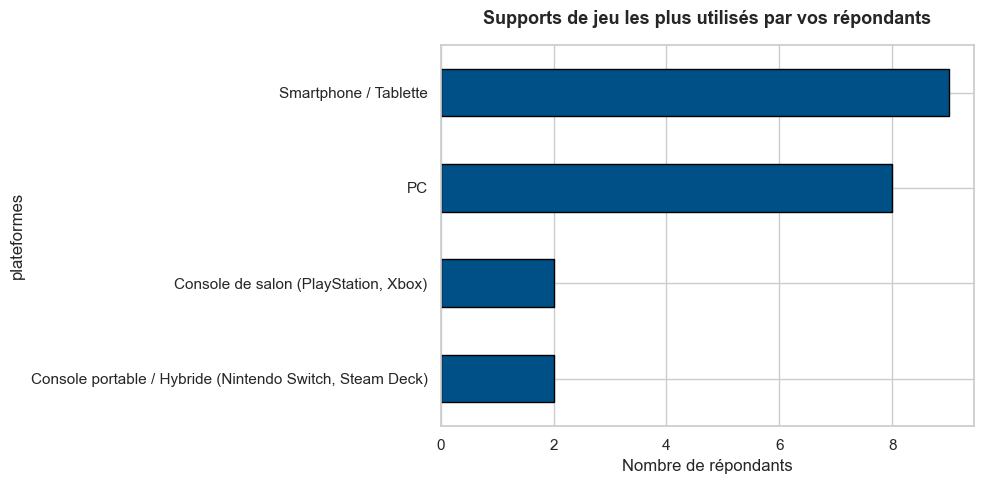

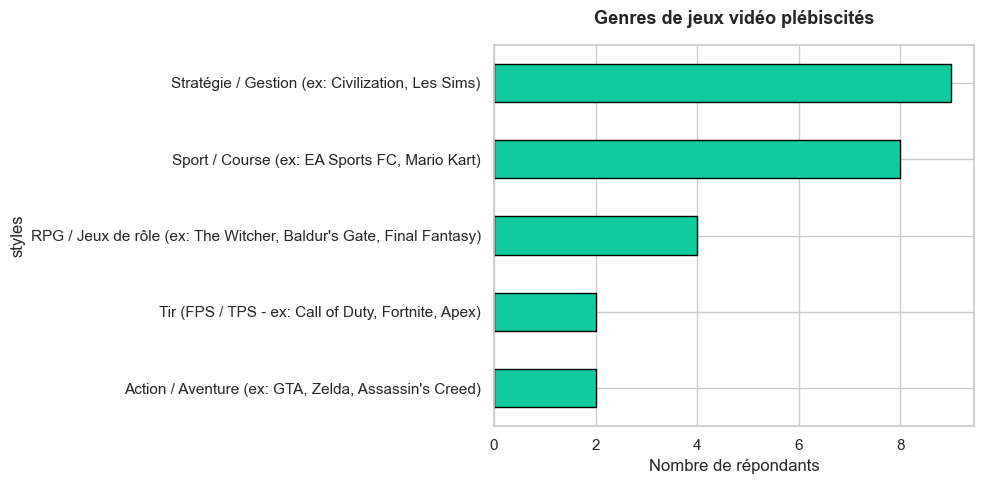

In [28]:
# Fonction pour nettoyer et compter les questions à choix multiples
def graph_choix_multiples(dataframe, nom_colonne, titre_graphique, couleur):
    # Séparer les réponses par le point-virgule et éclater le tableau
    df_exploded = dataframe[nom_colonne].str.split(';').explode()
    
    # Compter les occurrences et trier par ordre décroissant
    counts = df_exploded.value_counts().sort_values(ascending=True)
    
    # Générer le graphique en barres horizontales pour éviter le chevauchement des étiquettes
    plt.figure(figsize=(10, 5))
    counts.plot(kind='barh', color=couleur, edgecolor='black')
    plt.title(titre_graphique, fontsize=13, fontweight='bold', pad=15)
    plt.xlabel("Nombre de répondants")
    plt.tight_layout()
    plt.show()

# 1. Graphique des Plateformes les plus utilisées
graph_choix_multiples(df_survey, 'plateformes', "Supports de jeu les plus utilisés par vos répondants", '#005088')

# 2. Graphique des Styles de jeux préférés
graph_choix_multiples(df_survey, 'styles', "Genres de jeux vidéo plébiscités", '#11caa0')

In [29]:
# Calcul du coefficient de Spearman et de la p-value
coef, p_val_age_budget = stats.spearmanr(df_survey['age'], df_survey['budget_an'])

print("--- 🎯 TEST DE SPEARMAN : ÂGE vs BUDGET ---")
print(f"Coefficient de corrélation : {coef:.3f}")
print(f"p-value : {p_val_age_budget:.3f}")

if p_val_age_budget < 0.05:
    print("👉 Hypothèse CONFIRMÉE : Il existe un lien linéaire significatif entre l'âge et le budget.")
else:
    print("👉 Hypothèse INFIRMÉE : L'âge et le budget sont indépendants sur cet échantillon.")

--- 🎯 TEST DE SPEARMAN : ÂGE vs BUDGET ---
Coefficient de corrélation : 0.032
p-value : 0.921
👉 Hypothèse INFIRMÉE : L'âge et le budget sont indépendants sur cet échantillon.


In [30]:
# Création du tableau de contingence (croisement)
table_croisee = pd.crosstab(df_survey['genre'], df_survey['modele_eco'])
print("--- 📊 TABLEAU DE CROISEMENT GENRE / MODÈLE ÉCO ---")
print(table_croisee)

# Application du test du Chi-2
chi2, p_val_chi2, dof, expected = stats.chi2_contingency(table_croisee)

print("\n--- 🎯 TEST DU KHI-DEUX ($\chi^2$) ---")
print(f"p-value : {p_val_chi2:.3f}")

if p_val_chi2 < 0.05:
    print("👉 Hypothèse CONFIRMÉE : Le genre influence significativement la préférence du modèle économique.")
else:
    print("👉 Hypothèse INFIRMÉE : Le choix du modèle économique est indépendant du genre.")

--- 📊 TABLEAU DE CROISEMENT GENRE / MODÈLE ÉCO ---
modele_eco  Abonnement (Jeu inclus dans un service de type Game Pass, PlayStation Plus)  \
genre                                                                                     
Femme                                                       0                             
Homme                                                       2                             

modele_eco  Free-to-play (Jeu gratuit avec achats optionnels)  \
genre                                                           
Femme                                                       4   
Homme                                                       1   

modele_eco  Pay-to-play classique (Achat unique du jeu complet, ex: 70€)  
genre                                                                     
Femme                                                       3             
Homme                                                       2             

--- 🎯 TEST DU KHI-DEUX